# CardioCare — 01. EDA & 데이터 전처리

UCI Heart Disease 데이터셋(4개 기관 통합, 920행)을 탐색하고,
그 결과를 근거로 전처리 파이프라인을 구성한다.

**컬럼 설명**
| 컬럼 | 설명 |
|---|---|
| age | 나이 |
| sex | 성별 (1=남, 0=여) |
| cp | 흉통 유형 (1~4) |
| trestbps | 안정 시 혈압 (mm Hg) |
| chol | 혈중 콜레스테롤 (mg/dl) |
| fbs | 공복 혈당 > 120 (1=참) |
| restecg | 안정 시 심전도 (0~2) |
| thalach | 최대 심박수 |
| exang | 운동 유발 협심증 (1=예) |
| oldpeak | 운동 대비 ST 하강 |
| slope | 운동 ST 기울기 (1~3) |
| ca | 형광조영 혈관 수 (0~3) |
| thal | 탈리움 스캔 결과 (3/6/7) |
| target | 심장병 여부 (0=정상, 1=심장병) |

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from data import load_data, load_raw
from preprocessing import build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
RANDOM_STATE = 42

# 재현성
np.random.seed(RANDOM_STATE)

## 1. 데이터 로드

In [2]:
df = load_data(data_dir='..')
print(f'Shape: {df.shape}')
df.head()

Shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,cleveland,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,cleveland,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,cleveland,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  860 non-null    float64
 4   chol      718 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  source    920 non-null    object 
 14  target    920 non-null    int64  
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,860.000000,718.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.286047,246.832869,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.553261
std,9.424685,0.408148,0.930969,18.536175,58.527062,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,0.497426
min,28.000000,0.000000,1.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,210.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,239.500000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,276.750000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## 2. 타깃 클래스 분포

타깃 분포 (비율):
target
정상(0)     0.446739
심장병(1)    0.553261
Name: proportion, dtype: float64


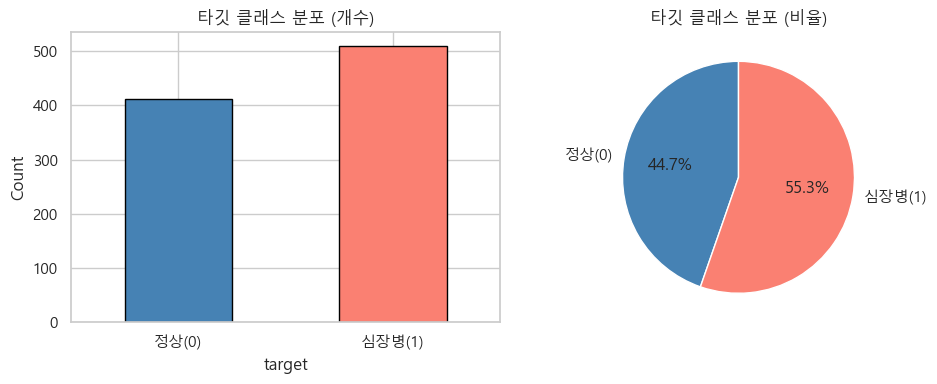


→ 클래스 불균형 (다수:소수): 1.24 :1  (심장병이 다수)


In [5]:
# value_counts는 빈도 내림차순 → sort_index()로 [0, 1] 순서 고정 (라벨 정합성)
target_counts = df['target'].value_counts().sort_index()
target_dist   = df['target'].value_counts(normalize=True).sort_index()
labels = ['정상(0)', '심장병(1)']

print('타깃 분포 (비율):')
print(target_dist.rename({0: '정상(0)', 1: '심장병(1)'}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('타깃 클래스 분포 (개수)')
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_ylabel('Count')

axes[1].pie(target_dist, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('타깃 클래스 분포 (비율)')

plt.tight_layout()
plt.savefig('../data/fig_target_dist.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('→ 클래스 불균형 (다수:소수):', round(target_dist[1] / target_dist[0], 2), ':1  (심장병이 다수)')

## 3. 결측값 분석

결측값이 있는 컬럼:
          결측 수  결측 비율(%)
ca         611      66.4
thal       486      52.8
slope      309      33.6
chol       202      22.0
fbs         90       9.8
oldpeak     62       6.7
trestbps    60       6.5
thalach     55       6.0
exang       55       6.0
restecg      2       0.2


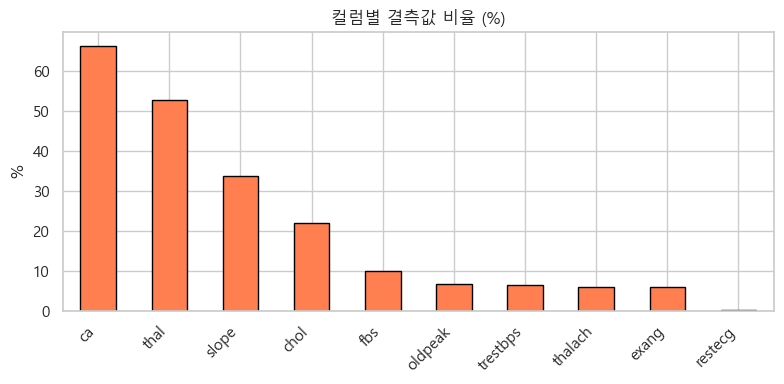

In [6]:
feat_cols = [c for c in df.columns if c not in ['source', 'target']]

missing = df[feat_cols].isnull().sum()
missing_pct = df[feat_cols].isnull().mean().mul(100).round(1)
missing_df = pd.DataFrame({'결측 수': missing, '결측 비율(%)': missing_pct})
missing_df = missing_df[missing_df['결측 수'] > 0].sort_values('결측 비율(%)', ascending=False)

print('결측값이 있는 컬럼:')
print(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('컬럼별 결측값 비율 (%)')
ax.set_ylabel('%')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/fig_missing.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# 기관별 결측값 패턴 확인
print('기관별 결측값 합계:')
print(df.groupby('source')[feat_cols].apply(lambda g: g.isna().sum()))

기관별 결측값 합계:
             age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
source                                                                    
cleveland      0    0   0         0     0    0        0        0      0   
hungarian      0    0   0         1    23    8        1        1      1   
switzerland    0    0   0         2   123   75        1        1      1   
va             0    0   0        57    56    7        0       53     53   

             oldpeak  slope   ca  thal  
source                                  
cleveland          0      0    4     2  
hungarian          0    190  291   266  
switzerland        6     17  118    52  
va                56    102  198   166  


## 4. 이상치 탐지 (연속형 특성)

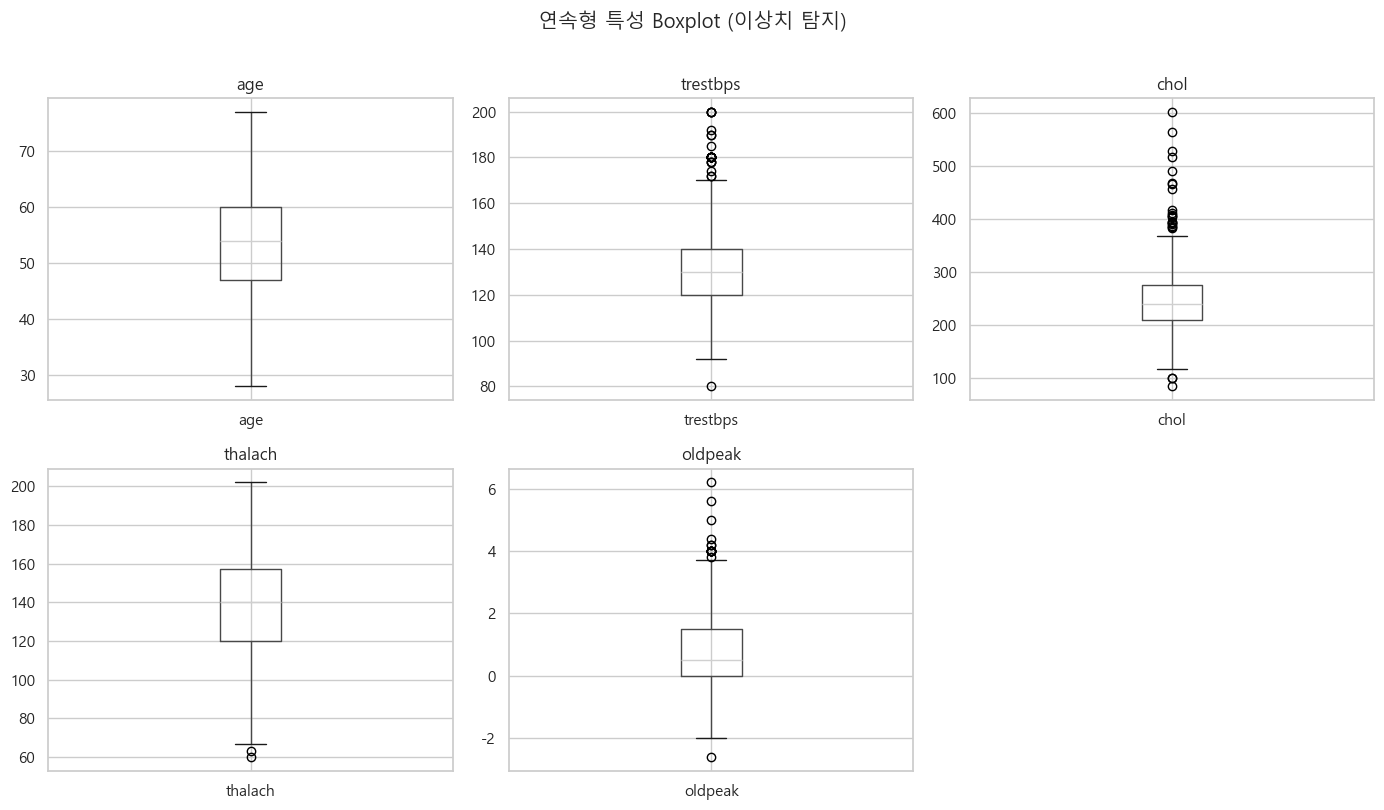

In [8]:
# Boxplot으로 이상치 시각화
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    df[[col]].boxplot(ax=axes[i])
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('연속형 특성 Boxplot (이상치 탐지)', y=1.01)
plt.tight_layout()
plt.savefig('../data/fig_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# IQR 기반 이상치 개수 보고
print('IQR 기반 이상치 개수:')
for col in NUMERIC_FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    print(f'  {col}: {len(outliers)}개 ({len(outliers)/len(df)*100:.1f}%)')

IQR 기반 이상치 개수:
  age: 0개 (0.0%)
  trestbps: 27개 (2.9%)
  chol: 23개 (2.5%)
  thalach: 2개 (0.2%)
  oldpeak: 16개 (1.7%)


## 5. 특성별 분포 (타깃 기준)

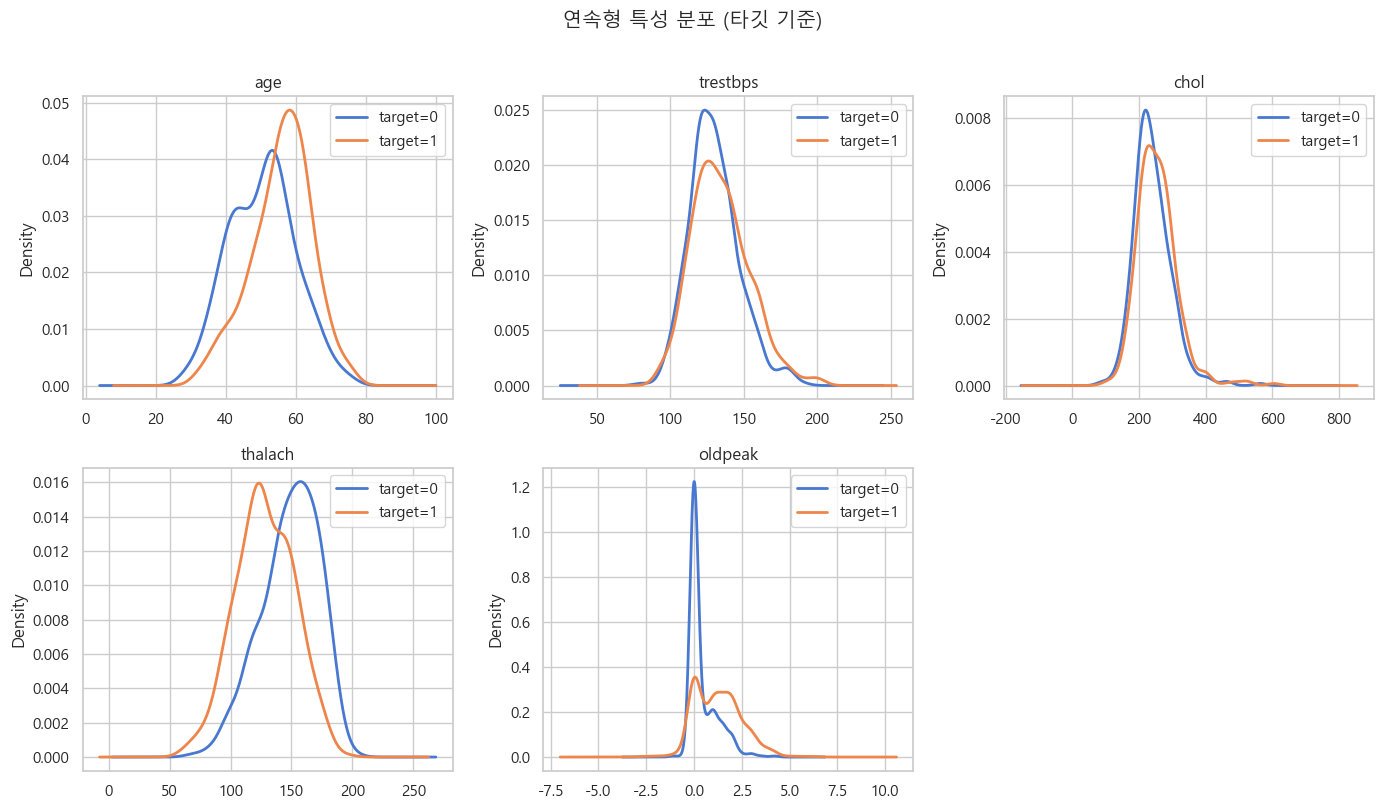

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    for label, grp in df.groupby('target'):
        grp[col].dropna().plot(kind='kde', ax=axes[i],
                               label=f'target={label}', linewidth=2)
    axes[i].set_title(col)
    axes[i].legend()

axes[-1].set_visible(False)
plt.suptitle('연속형 특성 분포 (타깃 기준)', y=1.01)
plt.tight_layout()
plt.show()

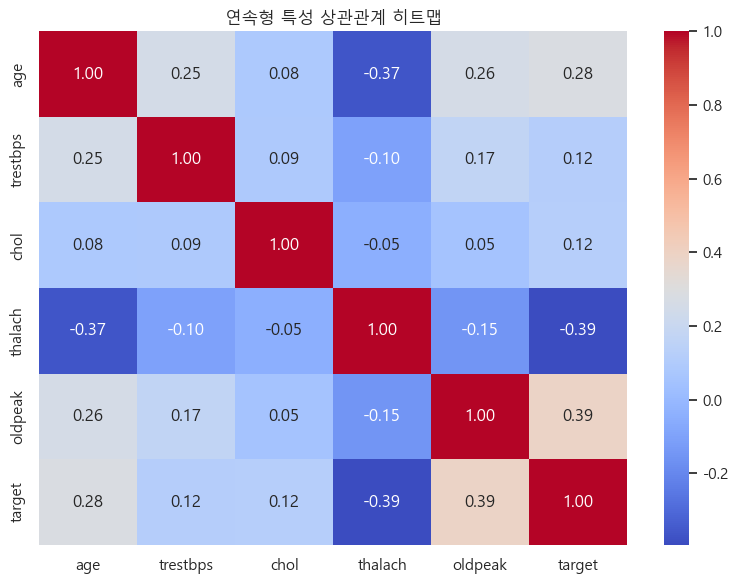

In [11]:
# 상관관계 히트맵
corr_cols = NUMERIC_FEATURES + ['target']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('연속형 특성 상관관계 히트맵')
plt.tight_layout()
plt.show()

## 6. 전처리 파이프라인 구성 및 검증

In [12]:
from sklearn.model_selection import train_test_split
from preprocessing import build_preprocessor, get_feature_names

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df[feature_cols]
y = df['target']

# 시드 고정, 80/20 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'학습: {X_train.shape}, 테스트: {X_test.shape}')
print(f'학습 타깃 분포: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'테스트 타깃 분포: {y_test.value_counts(normalize=True).round(3).to_dict()}')

학습: (736, 13), 테스트: (184, 13)
학습 타깃 분포: {1: 0.553, 0: 0.447}
테스트 타깃 분포: {1: 0.554, 0: 0.446}


In [13]:
# 학습 데이터에만 fit → 테스트는 transform만
preprocessor = build_preprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor)
print(f'전처리 후 특성 수: {X_train_processed.shape[1]}')
print(f'특성 이름: {feature_names}')

# NaN이 남아 있지 않은지 확인
assert not np.isnan(X_train_processed).any(), '학습 데이터에 NaN 잔존!'
assert not np.isnan(X_test_processed).any(), '테스트 데이터에 NaN 잔존!'
print('✓ 결측값 처리 완료 — NaN 없음')

전처리 후 특성 수: 28
특성 이름: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex_0.0', 'sex_1.0', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'exang_0.0', 'exang_1.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']
✓ 결측값 처리 완료 — NaN 없음


## 7. EDA 결과 요약 및 전처리 결정

### EDA가 알려준 것

1. **클래스 불균형**: 정상(0) vs 심장병(1)이 약 54:46 비율로 완만한 불균형이 존재한다. 극단적이지 않으나 `balanced_accuracy`와 `recall`을 주요 지표로 삼는 근거가 된다. 임상 맥락에서 **False Negative(심장병을 정상으로 오분류)의 위험이 더 크므로 recall을 우선시**해야 한다.

2. **결측값 패턴**: `slope`, `ca`, `thal`은 Swiss/VA 기관에서 결측 비율이 50~80%에 달한다. 단순 삭제하면 데이터의 상당량이 손실되므로, **중앙값/최빈값 대치**를 선택했다. 해당 컬럼이 심장병 예측과 임상적으로 중요한 특성이기 때문이다.

3. **이상치**: `chol=0` 값이 Switzerland 기관에서 다수 관찰된다(실제 콜레스테롤이 0일 수 없음 → 기록 누락). `trestbps`에서도 극단값이 존재한다. 이를 제거하기보단 **중앙값 대치 + StandardScaler**로 영향을 줄인다.

4. **분포 패턴**: `thalach`(최대 심박수)와 `oldpeak`(ST 하강)이 타깃과 가장 뚜렷한 차이를 보인다. `cp`(흉통 유형), `ca`(혈관 수), `thal`도 범주별 분포 차이가 크다.

### 전처리 결정

| 항목 | 결정 | 근거 |
|------|------|------|
| 결측 대치 (연속형) | 중앙값 | 이상치·왜도에 강건 |
| 결측 대치 (범주형) | 최빈값 | 가장 흔한 임상 상태로 보수적 대치 |
| 스케일링 | StandardScaler | Logistic Regression, SVC에 필요; 누수 방지를 위해 학습 fold에만 fit |
| 범주형 인코딩 | OneHotEncoder | 순서 관계 없는 명목형 변수 |
| 이상치 처리 | 삭제 안 함 | 920행의 한정된 데이터에서 정보 손실 최소화 |
| 중복 제거 | load 단계에서 확인 후 처리 | |

전처리는 `sklearn.Pipeline`으로 구성되어 **새 데이터에 그대로 재적용 가능**하며, 학습/테스트 분리 후 학습 데이터에만 `fit`한다.

## 7. EDA 결과 요약 및 전처리 결정

### EDA가 알려준 것

1. **클래스 불균형**: 심장병(1) 55.3% vs 정상(0) 44.7%로, 심장병 쪽이 근소하게 많은 완만한 불균형(약 1.24:1)이 존재한다. 극단적이지 않으나 단순 accuracy보다 `balanced_accuracy`와 `recall`을 주요 지표로 삼는 근거가 된다. 임상 맥락에서 **False Negative(심장병을 정상으로 오분류)의 위험이 더 크므로 recall을 우선시**해야 한다.

2. **결측값 패턴**: `slope`, `ca`, `thal`은 Switzerland/VA 기관에서 결측 비율이 50~90%에 달한다. 단순 삭제하면 데이터의 상당량이 손실되므로, **중앙값/최빈값 대치**를 선택했다. 해당 컬럼이 심장병 예측과 임상적으로 중요한 특성이기 때문이다.

3. **이상치**: `chol=0` 값이 Switzerland 기관에서 다수 관찰된다(실제 콜레스테롤이 0일 수 없음 → 기록 누락). `trestbps`에서도 극단값이 존재한다. 이를 제거하기보단 **중앙값 대치 + StandardScaler**로 영향을 줄인다.

4. **분포 패턴**: `thalach`(최대 심박수)와 `oldpeak`(ST 하강)이 타깃과 가장 뚜렷한 차이를 보인다. `cp`(흉통 유형), `ca`(혈관 수), `thal`도 범주별 분포 차이가 크다.

### 전처리 결정

| 항목 | 결정 | 근거 |
|------|------|------|
| 결측 대치 (연속형) | 중앙값 | 이상치·왜도에 강건 |
| 결측 대치 (범주형) | 최빈값 | 가장 흔한 임상 상태로 보수적 대치 |
| 스케일링 | StandardScaler | Logistic Regression, SVC에 필요; 누수 방지를 위해 학습 fold에만 fit |
| 범주형 인코딩 | OneHotEncoder | 순서 관계 없는 명목형 변수 |
| 이상치 처리 | 삭제 안 함 | 920행의 한정된 데이터에서 정보 손실 최소화 |
| 중복 제거 | load 단계에서 확인 후 처리 | |

전처리는 `sklearn.Pipeline`으로 구성되어 **새 데이터에 그대로 재적용 가능**하며, 학습/테스트 분리 후 학습 데이터에만 `fit`한다.